
# 5.4 📈 Analítica Financiera: Retornos, Riesgo, Bollinger y Optimización de Portafolio

En este notebook conectamos todo lo que hemos construido hasta ahora:

- Descarga paralela de datos
- Transformación a `pandas`
- Cálculo de retornos
- Volatilidad
- Bandas de Bollinger
- Sharpe ratio
- Optimización de portafolio con Markowitz
- Frontera eficiente

La idea no es solo mostrar código, sino entender **por qué estas métricas son útiles** en un sistema como **SmartPortfolio**.

---

## 🎯 Objetivo

Al finalizar este notebook podrás:

1. Entender cómo pasar de precios a retornos.
2. Interpretar el riesgo de un activo o de un portafolio.
3. Construir Bandas de Bollinger y leerlas correctamente.
4. Calcular el **Sharpe ratio** como medida de retorno ajustado por riesgo.
5. Entender la lógica de **Markowitz** para combinar activos.
6. Visualizar una aproximación a la **frontera eficiente**.

---

## 🧭 Mapa mental

```{mermaid}
flowchart LR
    A[Datos de precios] --> B[Retornos]
    B --> C[Riesgo / volatilidad]
    C --> D[Indicadores tecnicos]
    C --> E[Metricas de portafolio]
    E --> F[Markowitz]
    F --> G[Frontera eficiente]
    G --> H[Decision de inversion]
```



## 1) ¿Por qué no trabajamos directamente con precios?

El precio por sí solo dice poco sobre desempeño relativo.

Ejemplo:

- Un activo puede pasar de 10 a 12
- Otro puede pasar de 100 a 102

Ambos subieron **2 unidades**, pero no tuvieron el mismo desempeño porcentual.

Por eso en finanzas cuantitativas se trabaja con **retornos**.

### Fórmula del retorno simple

\[
R_t = \frac{P_t - P_{t-1}}{P_{t-1}}
\]

Los retornos son útiles porque:

- hacen comparables activos con escalas distintas,
- permiten medir riesgo,
- sirven como base para optimización de portafolios,
- conectan con modelos estadísticos y de machine learning.



## 2) Pipeline de análisis

```{mermaid}
flowchart LR
    A[Prices] --> B[Returns]
    B --> C[Volatility]
    B --> D[Sharpe Ratio]
    A --> E[Bollinger Bands]
    B --> F[Covariance Matrix]
    F --> G[Portfolio Optimization]
    G --> H[Efficient Frontier]
```


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)



## 3) Simulación de precios

Para que el notebook sea reproducible, generamos una base sintética de precios.
En producción, estos datos vendrían de un provider como:

- Yahoo Finance
- Alpha Vantage
- Polygon
- Binance

La simulación nos permite enfocarnos en los conceptos sin depender de internet.


In [2]:

tickers = ["AAPL", "MSFT", "NVDA", "TSLA", "AMZN"]
days = 252  # ~1 año bursátil

prices = pd.DataFrame(
    {
        ticker: 100 + np.cumsum(np.random.normal(loc=0.10, scale=1.2, size=days))
        for ticker in tickers
    }
)

prices.head()


,AAPL,MSFT,NVDA,TSLA,AMZN
0,100.696057,102.646587,99.319229,100.691981,101.359463
1,100.630140,103.985546,98.834678,101.013785,100.817181
2,101.507366,102.262302,98.223806,100.083755,102.498054
3,103.435002,101.781221,97.287017,101.024127,102.835173
4,103.254018,103.401514,97.445243,100.433362,105.425486



## 4) Visualización de precios

Esta gráfica muestra trayectorias simuladas de precios.

No debes leerla como una predicción real, sino como una forma de construir un caso de estudio
sobre el cual calcular métricas cuantitativas.


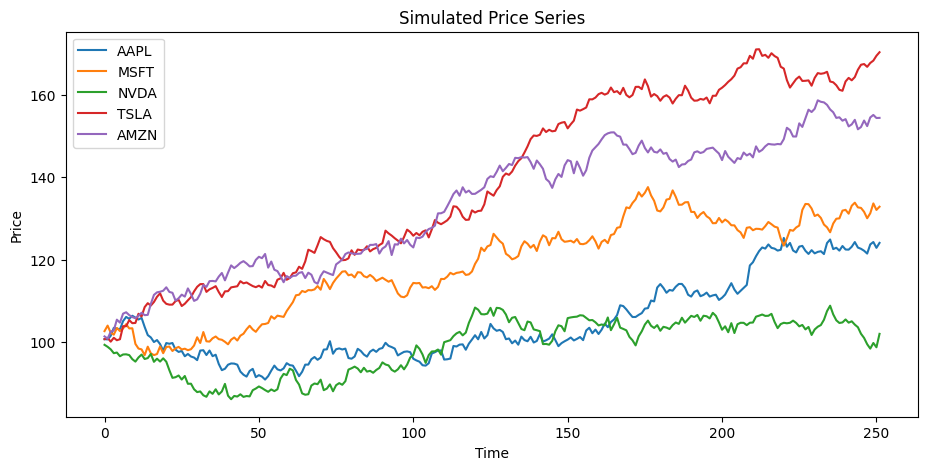

In [3]:

plt.figure(figsize=(11, 5))
for col in prices.columns:
    plt.plot(prices.index, prices[col], label=col)

plt.title("Simulated Price Series")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()



## 5) Retornos

Una vez tenemos precios, el siguiente paso es calcular retornos.

Esto transforma el problema de:

> “¿cuánto vale hoy?”

en:

> “¿cómo cambia su valor en el tiempo?”

Ese cambio de enfoque es fundamental para riesgo y optimización.


In [4]:

returns = prices.pct_change().dropna()
returns.head()


,AAPL,MSFT,NVDA,TSLA,AMZN
1,-0.000655,0.013044,-0.004879,0.003196,-0.005350
2,0.008717,-0.016572,-0.006181,-0.009207,0.016672
3,0.018990,-0.004704,-0.009537,0.009396,0.003289
4,-0.001750,0.015919,0.001626,-0.005848,0.025189
5,-0.001753,-0.007246,-0.009207,0.002453,-0.006896



## 6) Retorno esperado

Una forma simple de resumir el comportamiento promedio de un activo es su retorno medio.

En práctica suele anualizarse multiplicando por 252 días bursátiles.

\[
\mu = E[R]
\]


In [5]:

mean_returns = returns.mean() * 252
mean_returns


AAPL    0.225116
MSFT    0.271860
NVDA    0.045076
TSLA    0.537224
AMZN    0.434313
dtype: float64


## 7) Volatilidad: una medida básica de riesgo

La volatilidad mide qué tanto fluctúan los retornos.

Cuanto más dispersos sean los retornos, mayor incertidumbre.

$$
\sigma = \text{std}(R)
$$

Al anualizar:

$$
\sigma_{anual} = \sigma_{diaria} \sqrt{252}
$$

### ¿Por qué es útil?

Porque dos activos con el mismo retorno esperado no necesariamente tienen el mismo riesgo.


In [6]:

volatility = returns.std() * np.sqrt(252)
volatility


AAPL    0.176791
MSFT    0.160625
NVDA    0.192870
TSLA    0.133326
AMZN    0.151194
dtype: float64


## 8) Matriz de covarianza

Para construir portafolios no basta con medir el riesgo individual de cada activo.

También importa **cómo se mueven entre sí**.

La matriz de covarianza captura eso.

### Idea clave

Si dos activos no se mueven exactamente igual, combinarlos puede reducir riesgo.

Ese es el corazón de la teoría moderna de portafolio.


In [7]:

cov_matrix = returns.cov() * 252
cov_matrix


,AAPL,MSFT,NVDA,TSLA,AMZN
AAPL,0.031255,0.000814,0.002767,0.000391,0.002417
MSFT,0.000814,0.025800,-0.003033,0.000444,0.000424
NVDA,0.002767,-0.003033,0.037199,0.000712,0.001842
TSLA,0.000391,0.000444,0.000712,0.017776,0.000176
AMZN,0.002417,0.000424,0.001842,0.000176,0.022860



## 9) Bandas de Bollinger

Las Bandas de Bollinger combinan:

- una media móvil,
- una medida local de volatilidad.

Se usan para observar si el precio está relativamente “alto” o “bajo”
respecto a su comportamiento reciente.

$$
Upper = MA + 2\sigma
$$

$$
Lower = MA - 2\sigma
$$

### ¿Por qué sirven?

No “predicen el futuro”, pero ayudan a contextualizar el precio actual
frente a su variabilidad reciente.


In [8]:

ticker = "AAPL"
window = 20

ma = prices[ticker].rolling(window).mean()
std = prices[ticker].rolling(window).std()

upper = ma + 2 * std
lower = ma - 2 * std

bollinger_df = pd.DataFrame(
    {
        "price": prices[ticker],
        "ma": ma,
        "upper": upper,
        "lower": lower,
    }
)

bollinger_df.tail()


,price,ma,upper,lower
247,121.468606,122.586790,124.524319,120.649260
248,123.687151,122.702111,124.611744,120.792477
249,124.273129,122.800955,124.823449,120.778460
250,122.860068,122.867968,124.798451,120.937484
251,124.061502,122.977065,124.918940,121.035190


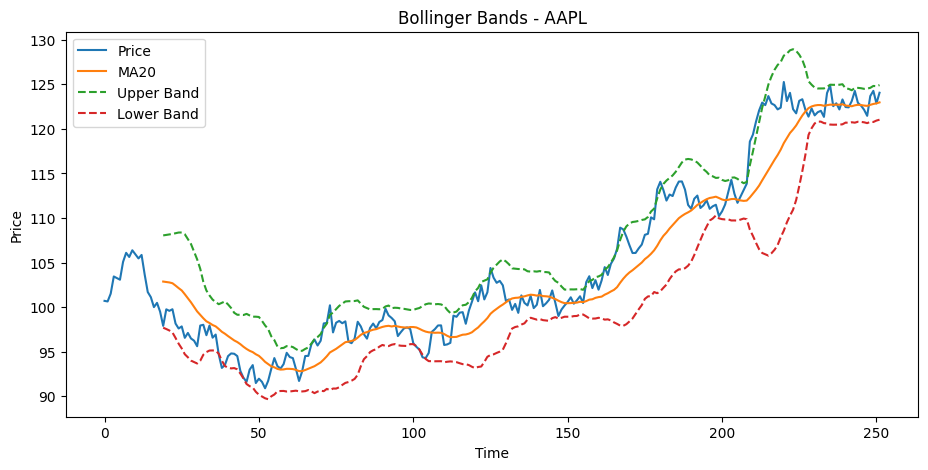

In [9]:

plt.figure(figsize=(11, 5))
plt.plot(bollinger_df["price"], label="Price")
plt.plot(bollinger_df["ma"], label="MA20")
plt.plot(bollinger_df["upper"], linestyle="--", label="Upper Band")
plt.plot(bollinger_df["lower"], linestyle="--", label="Lower Band")
plt.title(f"Bollinger Bands - {ticker}")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()



## 10) Sharpe Ratio

El Sharpe ratio resume cuánto retorno obtienes por unidad de riesgo.

$$
Sharpe = \frac{E[R_p] - R_f}{\sigma_p}
$$

donde:

- $E[R_p]$: retorno esperado del portafolio
- $R_f$: tasa libre de riesgo
- $\sigma_p$: volatilidad del portafolio

### ¿Por qué es útil?

Porque no basta con decir “este portafolio retorna más”.
También importa **cuánto riesgo asumió** para lograrlo.


In [10]:

risk_free_rate = 0.02  # 2% anual, valor de ejemplo

weights_equal = np.array([1 / len(tickers)] * len(tickers))

portfolio_return_equal = float(np.dot(weights_equal, mean_returns))
portfolio_vol_equal = float(np.sqrt(weights_equal.T @ cov_matrix.values @ weights_equal))
portfolio_sharpe_equal = (portfolio_return_equal - risk_free_rate) / portfolio_vol_equal

portfolio_return_equal, portfolio_vol_equal, portfolio_sharpe_equal


(0.30271777718454534, 0.077148926666136, 3.6645717497537444)


## 11) Teoría de Markowitz: combinar activos para optimizar riesgo y retorno

Harry Markowitz formalizó una idea poderosa:

> un portafolio debe evaluarse como conjunto, no como suma aislada de activos.

### Componentes

- Vector de retornos esperados: $\mu$
- Matriz de covarianza: $\Sigma$
- Pesos del portafolio: $w$

### Fórmulas

Retorno esperado del portafolio:

$$
E[R_p] = w^T \mu
$$

Varianza del portafolio:

$$
\sigma_p^2 = w^T \Sigma w
$$

Volatilidad del portafolio:

$$
\sigma_p = \sqrt{w^T \Sigma w}
$$

### Idea central

La diversificación no consiste solo en “comprar varias cosas”.
Consiste en combinar activos con comportamientos distintos.



## 12) Simulación Monte Carlo de portafolios

En lugar de resolver el problema con optimización exacta desde el inicio,
vamos a generar muchos portafolios aleatorios.

Esto permite:

- visualizar el espacio riesgo-retorno,
- identificar portafolios interesantes,
- introducir de forma intuitiva la frontera eficiente.


In [11]:

n_portfolios = 5000

results = []
weights_list = []

for _ in range(n_portfolios):
    weights = np.random.random(len(tickers))
    weights = weights / weights.sum()

    port_return = float(np.dot(weights, mean_returns))
    port_vol = float(np.sqrt(weights.T @ cov_matrix.values @ weights))
    port_sharpe = (port_return - risk_free_rate) / port_vol

    results.append((port_return, port_vol, port_sharpe))
    weights_list.append(weights)

results_df = pd.DataFrame(results, columns=["return", "volatility", "sharpe"])
results_df.head()


,return,volatility,sharpe
0,0.329747,0.083315,3.717775
1,0.331285,0.083463,3.729634
2,0.234059,0.087621,2.443009
3,0.290020,0.082179,3.285760
4,0.355296,0.083262,4.027014



## 13) Frontera eficiente (aproximación visual)

La frontera eficiente representa combinaciones de portafolios que ofrecen:

- el mayor retorno posible para un nivel de riesgo dado,
- o el menor riesgo posible para un nivel de retorno dado.

En esta versión usamos simulación Monte Carlo para obtener una aproximación visual.


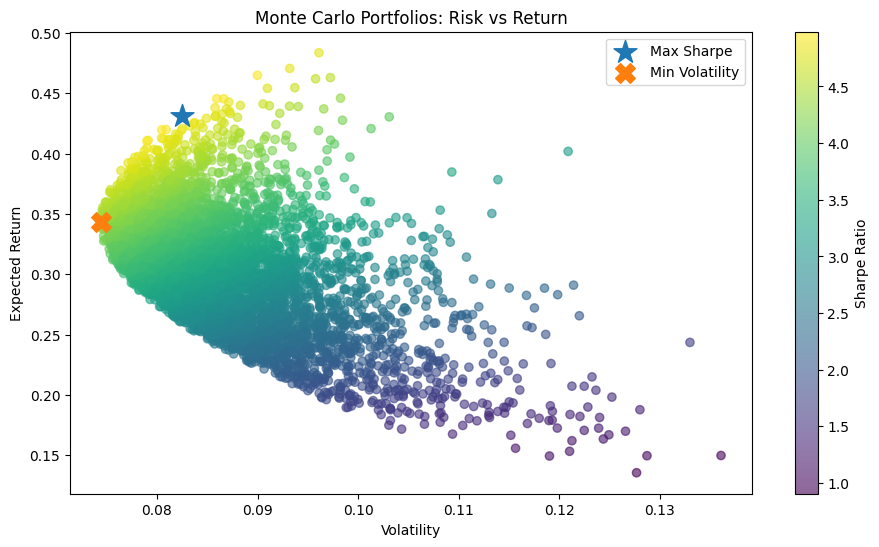

In [12]:

max_sharpe_idx = results_df["sharpe"].idxmax()
min_vol_idx = results_df["volatility"].idxmin()

max_sharpe_port = results_df.loc[max_sharpe_idx]
min_vol_port = results_df.loc[min_vol_idx]

plt.figure(figsize=(11, 6))
scatter = plt.scatter(
    results_df["volatility"],
    results_df["return"],
    c=results_df["sharpe"],
    cmap="viridis",
    alpha=0.6,
)
plt.colorbar(scatter, label="Sharpe Ratio")

plt.scatter(
    max_sharpe_port["volatility"],
    max_sharpe_port["return"],
    marker="*",
    s=300,
    label="Max Sharpe",
)

plt.scatter(
    min_vol_port["volatility"],
    min_vol_port["return"],
    marker="X",
    s=200,
    label="Min Volatility",
)

plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Monte Carlo Portfolios: Risk vs Return")
plt.legend()
plt.show()



## 14) ¿Qué portafolio fue mejor según Sharpe?

El portafolio con mayor Sharpe es, bajo esta métrica, el que mejor balancea
retorno esperado y riesgo.


In [13]:

best_weights = pd.Series(weights_list[max_sharpe_idx], index=tickers, name="weight")
best_weights.sort_values(ascending=False)


TSLA    0.442817
AMZN    0.299056
MSFT    0.181364
AAPL    0.057229
NVDA    0.019534
Name: weight, dtype: float64


## 15) Portafolio de mínima volatilidad

A veces el objetivo no es maximizar retorno, sino construir un portafolio más defensivo.

Ese sería el caso de un inversionista muy adverso al riesgo.


In [14]:

min_vol_weights = pd.Series(weights_list[min_vol_idx], index=tickers, name="weight")
min_vol_weights.sort_values(ascending=False)


TSLA    0.275884
AMZN    0.229874
MSFT    0.210069
NVDA    0.143691
AAPL    0.140482
Name: weight, dtype: float64


## 16) Comparación rápida entre portafolios relevantes


In [15]:

summary_df = pd.DataFrame(
    {
        "Equal Weight": [portfolio_return_equal, portfolio_vol_equal, portfolio_sharpe_equal],
        "Max Sharpe": [
            max_sharpe_port["return"],
            max_sharpe_port["volatility"],
            max_sharpe_port["sharpe"],
        ],
        "Min Volatility": [
            min_vol_port["return"],
            min_vol_port["volatility"],
            min_vol_port["sharpe"],
        ],
    },
    index=["Expected Return", "Volatility", "Sharpe"],
)

summary_df


,Equal Weight,Max Sharpe,Min Volatility
Expected Return,0.302718,0.430845,0.343260
Volatility,0.077149,0.082446,0.074434
Sharpe,3.664572,4.983223,4.342938



## 17) ¿Cómo conecta esto con SmartPortfolio?

Todo este notebook tiene una lectura arquitectónica:

```{mermaid}
flowchart LR
    A[Provider / API] --> B[Prices DataFrame]
    B --> C[Returns Engine]
    C --> D[Risk Metrics]
    D --> E[Indicators]
    D --> F[Portfolio Optimizer]
    E --> G[Alerts / Dashboards]
    F --> G
```

En SmartPortfolio estas piezas pueden vivir como:

- métodos de `Instrumento`,
- utilidades de analítica,
- una clase `OptimizadorPortafolio`,
- dashboards o reportes automáticos.



## 18) Ideas clave que deben quedar

### Sobre retornos
Trabajamos con retornos porque son comparables y modelables.

### Sobre volatilidad
Riesgo no es solo “caer”; también es incertidumbre.

### Sobre Bollinger
Es una herramienta descriptiva útil para contextualizar precios.

### Sobre Sharpe
No basta con ganar más; importa cuánto riesgo asumiste.

### Sobre Markowitz
La decisión óptima no es escoger el “mejor activo”, sino la mejor combinación.



## 🎯 Cierre

Este notebook muestra el paso de:

- datos descargados,
- a métricas financieras,
- a decisiones de portafolio.

Eso es exactamente lo que necesitas en un sistema como **SmartPortfolio**:
no solo almacenar datos, sino convertirlos en inteligencia cuantitativa.

En la siguiente sección esto puede desembocar naturalmente en:

- clases de optimización,
- reglas de alerta,
- recomendaciones automáticas,
- y un proyecto integrador mucho más sólido.
